# Generation of Black Hole Images: Thin Disk and Parametrized Models

This notebook generates black hole images for both **thin-disk** and **parametrized analytical models**.  
It works by computing geodesics for each pixel on the image plane and performing **forward integration of the intensity** along those geodesics.

Unlike the `ComputeGeodesics` notebook, this implementation is designed to be **memory efficient**:  
- It does **not** store all geodesic points in memory.  
- Instead, once the intensity for a pixel has been computed, the geodesic is discarded.  

As a result, this approach focuses directly on the **final intensity map**, avoiding the large memory overhead associated with retaining the full geodesic trajectories.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
include("../src/main.jl")


Using model: analytic, change src/set_globals.jl to modify.


main (generic function with 1 method)

### Analytic Parameters

In this cell we define the main parameters for the analytic model, including the observer position and screen setup, black hole spin, integration ranges, and observing frequency.  

These are the parameters used in the paper

**Remember:** 
- always update the black hole mass in `set_globals.jl`, not here.
- In `set_globals.jl` you can switch between "analytic" and "thin_disk"


In [6]:
#Analytic parameters
# MBH = 4.063e6! change in set_globals.jl

#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Size of the screen in Rg in both directions
const DXsize = 30.0
const DYsize = 30.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 256
const pixels_x = 256
const pixels_y = 256
# Distance to the source in parsecs
const SourceD = 7.778e3 * PC
const bhspin = 0.9
const Rout = 1000.0
const Rstop = 10000.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);

const cstartx = MVec4(0.0, log(Rh), 0.0, 0.0)
const cstopx = MVec4(0.0, log(1000.0), 1.0, 2.0 * π)
# Frequency observed by the camera in Hz
const freq = 230e9


2.3e11

In [3]:
const params = GlobalParams(bhspin, Rout, cstartx, cstopx);

These are the parameters used in the paper for the thin disk model

If you want to use "thin_disk" model, ***remember to change it in in `set_globals.jl`***


In [2]:
#THIN DISK PARAMETERS
# MBH = 10! change in set_globals.jl

## REMEMBER TO CHANGE BLACK HOLE MASS IN PARAMETERS.JL

#Setting up the parameters
#Observer distance in Rg
const ro = 10000.0
#Observer inclination in degrees
const th = 75.0

#Observer azimuth in degrees
const phi = 0.0

# Size of the screen in Rg in both directions
const DXsize = 40.0
const DYsize = 40.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 256
const pixels_x = 256
const pixels_y = 256

# Distance to the source in parsecs
const SourceD = 0.05 * PC
const Rout = 1000.0
const Rstop = 10000.0

# Frequency observed by the camera in Hz
const freq = 2.417989e17#230e9
const bhspin = 0.99
const Rh = 1 + sqrt(1. - bhspin * bhspin);
const cstartx = MVec4(0.0, log(Rh), 0.0, 0.0)
const cstopx = MVec4(0.0, log(1000.0), 1.0, 2.0 * π);
const Mdotedd = 4 * π * GNEWT * MBH * MSUN * MP/(0.1)/CL/SIGMA_THOMPSON
const Mdot = 0.01 * Mdotedd 
const z1 = 1.0 + (1.0 - bhspin^2)^(1.0 / 3.0) * ((1.0 + bhspin)^(1.0 / 3.0) + (1.0 - bhspin)^(1.0 / 3.0))
const z2 = sqrt(3.0 * bhspin^2 + z1^2)
const r_isco = 3.0 + z2 - copysign(sqrt((3.0 - z1) * (3.0 + z1 + 2.0 * z2)), bhspin)
const T0 = (3.0 / (8.0)/π * GNEWT * MBH * MSUN * Mdot / L_unit^3 / SIG)^(1.0 / 4.0);

In [3]:
const params = GlobalParams(bhspin, Rout, cstartx, cstopx);

### Image Generation

This cell performs the **ray tracing and radiative transfer** to build the black hole image:

1. **Camera setup**:  
   The observer’s position is converted into native coordinates (`Xcamera`).  

2. **Scaling**:  
   A `scale_factor` accounts for the physical pixel size on the image plane relative to the source distance.  

3. **Geodesic integration**:  
   - For each pixel `(i, j)`, a geodesic is computed starting from the camera.  
   - The geodesic is traced with a maximum of `maxnstep` integration steps (There is no problem in case it overwhelms it. The array will dynamically increase, but a warning will pop up).  
   - Emission along the geodesic is integrated into the corresponding pixel intensity.  

4. **Final normalization**:  
   After the geodesics are integrated, the image intensity is scaled by `freq³` to ensure proper units, converting from the covariant intensity to the one measured.  

In short, this loop computes the **final intensity map** pixel by pixel by tracing geodesics and integrating emission along each trajectory.


In [7]:
using ProgressMeter

ProgressMeter.ijulia_behavior(:clear)
const Xcamera = MVec4(camera_position(ro, th, phi, bhspin, Rout))

const scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)
const freq_unitless = freq * HPL / (ME * CL * CL)
const maxnstep = 15000

Image = zeros(Float64, pixels_x, pixels_y)

println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")


p = Progress(
    pixels_x * pixels_y; 
    desc = "Computing Image...", 
    showspeed = true, 
    barlen = 30
)

# --- Main Computation Loop ---
Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid()
    for j in 0:(pixels_y - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)
        empty!(traj)

        nstep = get_pixel(traj, i, j, Xcamera, maxnstep, fovx, fovy, freq_unitless, pixels_x, pixels_y, bhspin, Rh, Rout, Rstop)
       
        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image, i + 1, j + 1, freq, bhspin)
        ProgressMeter.next!(p)
    end
end

Image .*= freq^3
finish!(p)

Utilizing 3 threads for geodesic calculation.


Computing Image... 100%|██████████████████████████████| Time: 0:00:30 ( 0.47 ms/it)


### Diagnostics from `OutputStokesParameters`

After generating the image, `OutputStokesParameters` prints basic diagnostics about the intensity map:

- **Scale**: normalization factor applied to convert pixel values into physical units.  
- **imax, jmax**: pixel indices `(i, j)` where the maximum intensity `Imax` is located.  
- **Imax**: maximum specific intensity in the image (at the brightest pixel).  
- **Iavg**: average specific intensity across all pixels.  
- **freq_cgs**: observing frequency in cgs units (Hz).  
- **Ftot**: total flux density (in cgs units, e.g. erg s⁻¹ cm⁻² Hz⁻¹) obtained by summing all pixel intensities.  
- **νLν (nuLnu)**: luminosity at frequency ν, computed as `ν × Lν`, where `Lν` is the spectral luminosity corresponding to `Ftot`.


In [8]:
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)

Image processing complete. Calculating total flux and averages...
Scale = 8.586265738027388e-01
imax = 91, jmax = 118, Imax = 9.694337940975214e-7, Iavg = 4.602983896146021e-7
Total Flux Fnu = 2.590142819216279e-02 Jy
nuLnu = 4.312196050171153e32


In [5]:
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)

Image processing complete. Calculating total flux and averages...
Scale = 2.237608086843551e-01
imax = 109, jmax = 135, Imax = 19007.867654192312, Iavg = 467.7402542124241
Total Flux Fnu = 6.859124738411620e+06 Jy
nuLnu = 4.961055695316561e36


Plotting the final image with the appropriate angular spacing 

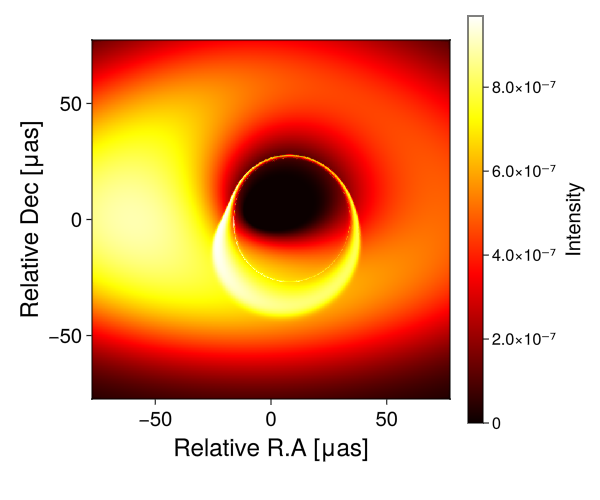

In [14]:
using WGLMakie
using Printf


d_kpc = 7.78
d_cm = d_kpc * 3.086e21           
fov_rg = 30
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm   
theta_μas = theta_rad * MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)


Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)
hm = heatmap!(ax, x, y, Image; colormap=:hot, colorrange=crange)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig

In [ ]:
using WGLMakie
using Printf


d_kpc = 7.78
d_cm = d_kpc * 3.086e21           
fov_rg = 30
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm   
theta_μas = theta_rad * MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)


Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)
hm = heatmap!(ax, x, y, Image; colormap=:hot, colorrange=crange)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig

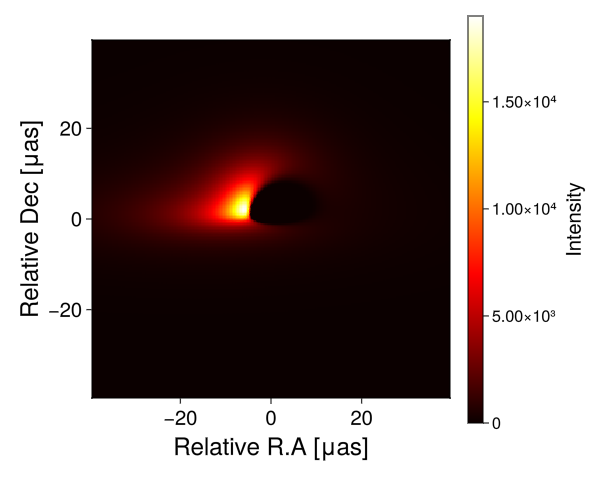

In [9]:
using WGLMakie
using Printf


d_kpc = 0.05 * 1/1000
d_cm = d_kpc * 3.086e21           
fov_rg = 40
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm   
theta_μas = theta_rad * MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)


Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)
hm = heatmap!(ax, x, y, Image; colormap=:hot, colorrange=crange)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig